In [1]:
# -----------------------------
# 1. 导入库
# -----------------------------
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

# -----------------------------
# 2. 设置路径和读取数据
# -----------------------------
df = pd.read_csv(r"E:\00论文\2025江苏人民公社\【submit1】heritage science\0630\Extract_commune_with_cluster.csv")

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [3]:
# 2. 特征归一化
# -----------------------
features = [
    'Elevation', 'Precipitation', 'Temperature', 'Wind',
    'Distance to canal', 'Distance to railway', 'Distance to ocean',
    'Distance to river', 'Distance to road', 'Distance to central city'
]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[features])
X = pd.DataFrame(X_scaled, columns=features)
y = df['cluster']  # cluster列为0/1/2

# -----------------------
# 3. 划分训练集与测试集
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------
# 4. 训练 XGBoost 模型
# -----------------------
model = XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss")
model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_bin=256, max_cat_to_onehot=4, max_delta_step=0, max_depth=6,
              max_leaves=0, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=0,
              num_class=3, num_parallel_tree=1, objective='multi:softprob',
              predictor='auto', random_state=0, ...)

In [4]:
# -----------------------
# 5. 计算 SHAP 值
# -----------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # 是个长度为3的list


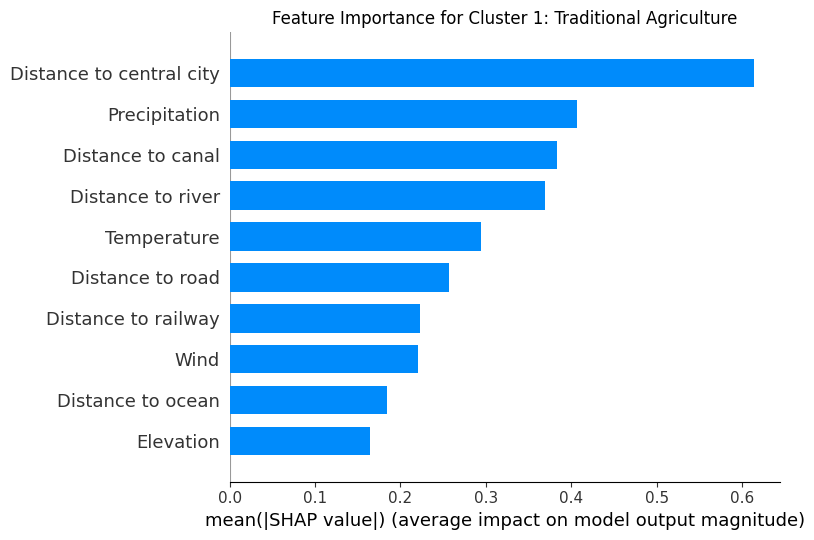

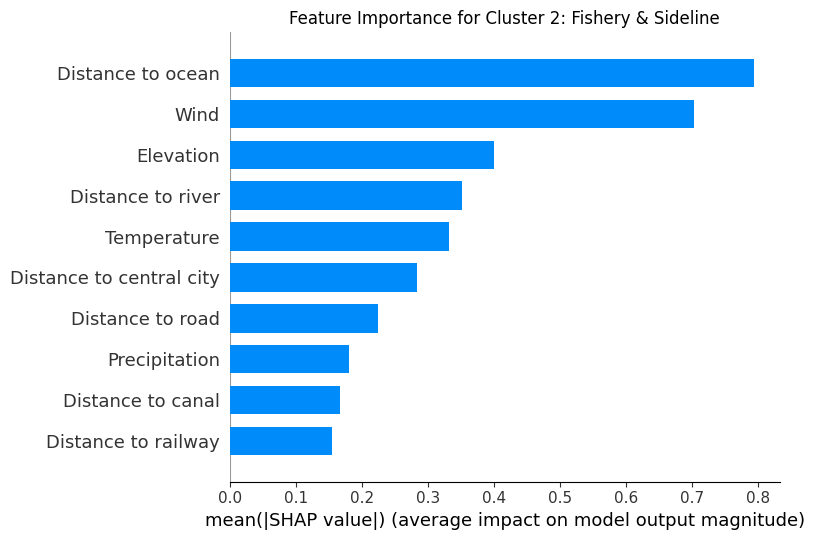

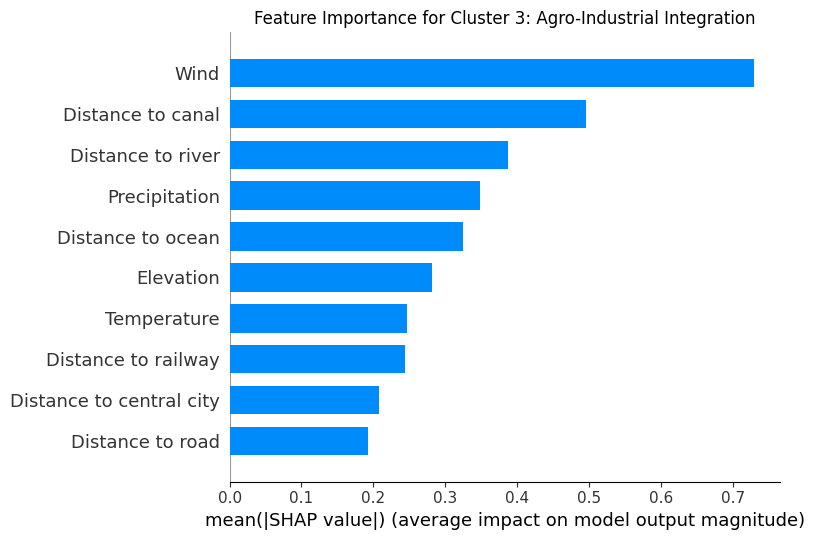

In [6]:
# -----------------------
# 6. 可视化：每一类的影响因子（bar图）
# -----------------------
cluster_names = {
    0: "Traditional Agriculture",
    1: "Fishery & Sideline",
    2: "Agro-Industrial Integration"
}

for i in range(3):  # i = 0, 1, 2
    plt.figure()
    shap.summary_plot(shap_values[i], X_test, plot_type="bar", show=False)
    plt.title(f"Feature Importance for Cluster {i+1}: {cluster_names[i]}")
    plt.tight_layout()
    plt.savefig(fr"E:\00论文\2025江苏人民公社\【submit1】heritage science\0630\shap_cluster_{i+1}.png", dpi=300)
    plt.show()

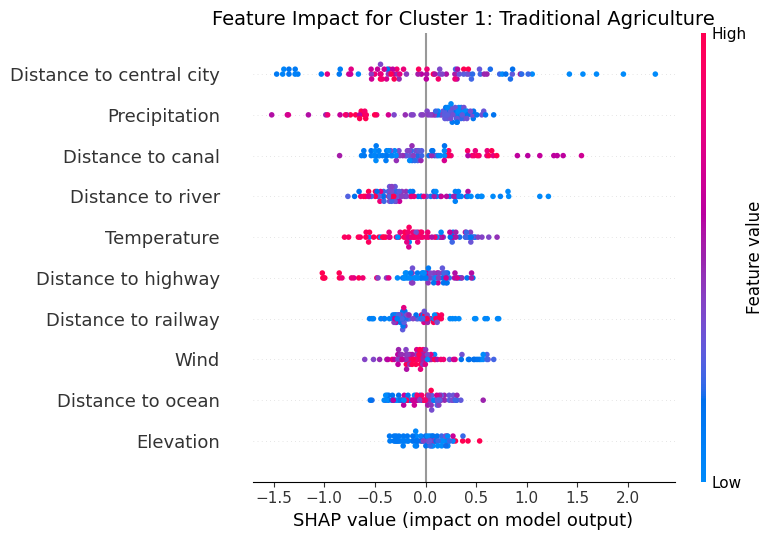

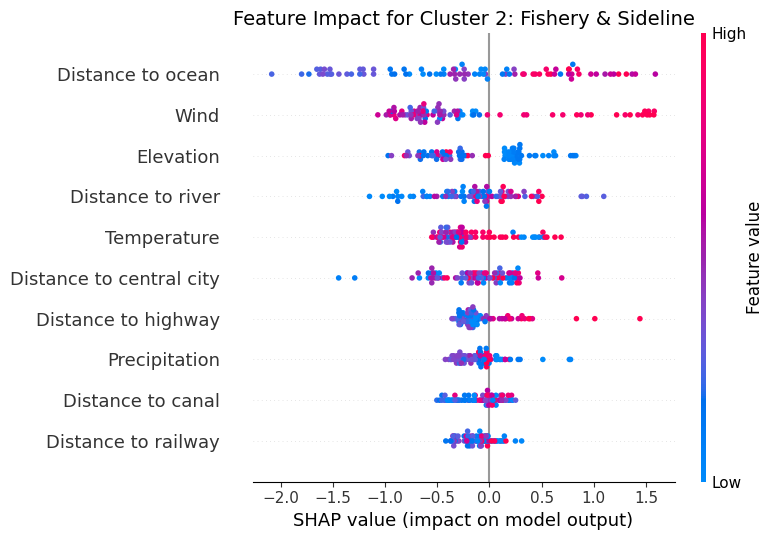

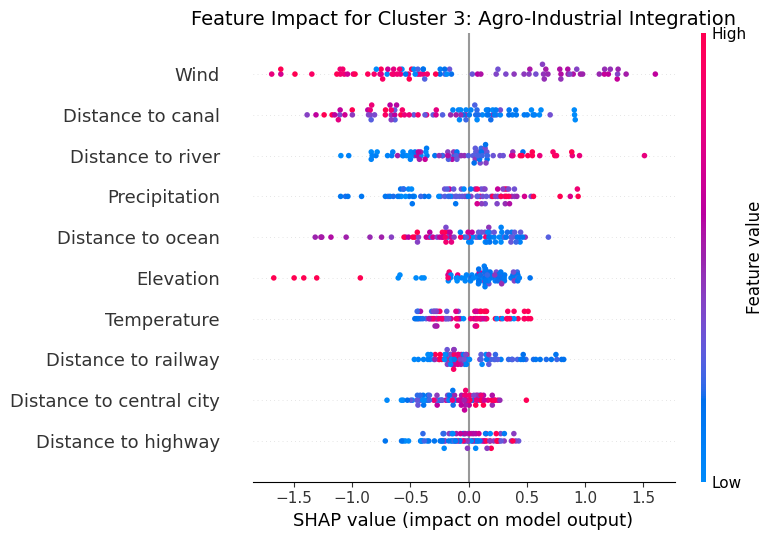

In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------
# 1. 初始化 SHAP Explainer
# -----------------------
explainer = shap.TreeExplainer(model)  # model 是你训练好的 LGBMClassifier
shap_values = explainer.shap_values(X_test)

# -----------------------
# 2. 可视化：蜂群图（Beeswarm）
# -----------------------
cluster_names = {
    1: "Traditional Agriculture",
    2: "Fishery & Sideline",
    3: "Agro-Industrial Integration"
}

# -----------------------
# 3. 绘制每类的 SHAP beeswarm 图
# -----------------------
for i in range(3):
    plt.figure()
    shap.summary_plot(shap_values[i], X_test, plot_type="dot", show=False)
    plt.title(f"Feature Impact for Cluster {i+1}: {cluster_names[i+1]}", fontsize=14)
    plt.tight_layout()
    plt.savefig(fr"E:\00论文\heritage science\0630\shap_beeswarm_cluster_{i+1}.png", dpi=600)
    plt.show()

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

# -----------------------
# 1. 读取与归一化数据（略，可参考你已有的 X 和 y）
# -----------------------
# X: 自变量特征（已归一化）
# y: 因变量 cluster（0,1,2）

# -----------------------
# 2. 划分训练测试集
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------
# 3. 训练模型
# -----------------------
model = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', use_label_encoder=False)
model.fit(X_train, y_train)

# -----------------------
# 4. 预测并评估
# -----------------------
y_pred = model.predict(X_test)

# ✅ 准确率
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# ✅ 分类报告
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ✅ 混淆矩阵
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ✅ AUC（多分类 One-vs-Rest）
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_prob = model.predict_proba(X_test)
auc_score = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f"AUC (One-vs-Rest macro): {auc_score:.4f}")


Accuracy: 0.4713

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.68      0.61        41
           1       0.33      0.18      0.23        17
           2       0.37      0.34      0.36        29

    accuracy                           0.47        87
   macro avg       0.42      0.40      0.40        87
weighted avg       0.45      0.47      0.45        87

Confusion Matrix:
[[28  2 11]
 [ 8  3  6]
 [15  4 10]]
AUC (One-vs-Rest macro): 0.5211


In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f"5折交叉验证 Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"各折结果: {cv_scores.round(4)}")

5折交叉验证 Accuracy: 0.4531 ± 0.0521
各折结果: [0.4483 0.5345 0.4828 0.4138 0.386 ]


In [9]:
import numpy as np
import pandas as pd

# 确保变量存在
shap_importance = {}
for i in range(3):
    mean_abs_shap = np.abs(shap_values[i]).mean(axis=0)
    shap_importance[f'Cluster {i}'] = pd.Series(
        mean_abs_shap, index=X_test.columns
    ).sort_values(ascending=False)

# 打印三类的完整SHAP值
cluster_names = {
    0: "Traditional Agriculture",
    1: "Fishery & Sideline", 
    2: "Agro-Industrial Integration"
}

for i in range(3):
    print(f"\n{'='*50}")
    print(f"Cluster {i}: {cluster_names[i]}")
    print(f"{'='*50}")
    print(shap_importance[f'Cluster {i}'].round(4).to_string())


Cluster 0: Traditional Agriculture
Distance to central city    0.6136
Precipitation               0.4070
Distance to canal           0.3830
Distance to river           0.3686
Temperature                 0.2943
Distance to road            0.2567
Distance to railway         0.2233
Wind                        0.2201
Distance to ocean           0.1845
Elevation                   0.1638

Cluster 1: Fishery & Sideline
Distance to ocean           0.7939
Wind                        0.7031
Elevation                   0.4009
Distance to river           0.3525
Temperature                 0.3324
Distance to central city    0.2836
Distance to road            0.2250
Precipitation               0.1812
Distance to canal           0.1672
Distance to railway         0.1552

Cluster 2: Agro-Industrial Integration
Wind                        0.7292
Distance to canal           0.4952
Distance to river           0.3870
Precipitation               0.3489
Distance to ocean           0.3251
Elevation         

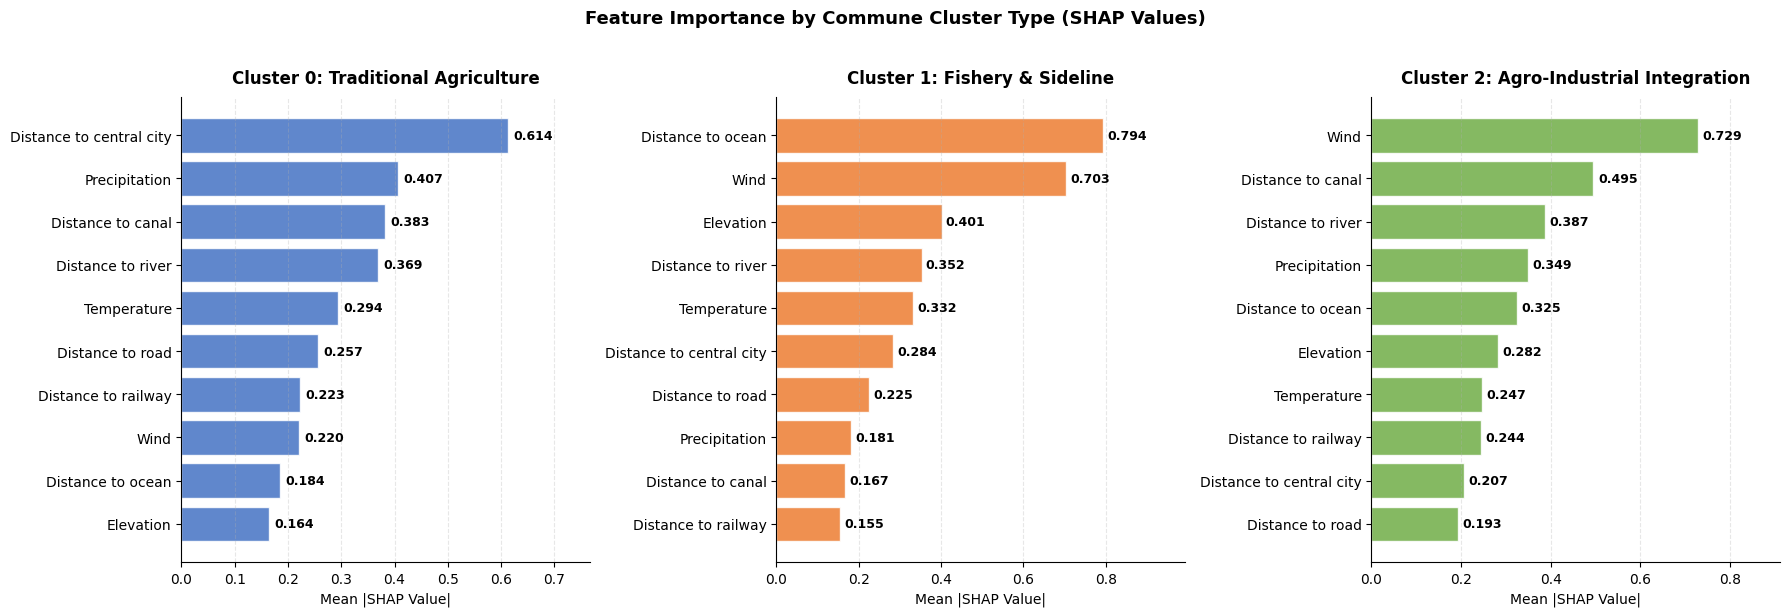

图已保存


In [10]:
cluster_names = {
    0: "Traditional Agriculture",
    1: "Fishery & Sideline",
    2: "Agro-Industrial Integration"
}

shap_data = {
    0: {"Distance to central city":0.6136,"Precipitation":0.4070,
        "Distance to canal":0.3830,"Distance to river":0.3686,
        "Temperature":0.2943,"Distance to road":0.2567,
        "Distance to railway":0.2233,"Wind":0.2201,
        "Distance to ocean":0.1845,"Elevation":0.1638},
    1: {"Distance to ocean":0.7939,"Wind":0.7031,"Elevation":0.4009,
        "Distance to river":0.3525,"Temperature":0.3324,
        "Distance to central city":0.2836,"Distance to road":0.2250,
        "Precipitation":0.1812,"Distance to canal":0.1672,
        "Distance to railway":0.1552},
    2: {"Wind":0.7292,"Distance to canal":0.4952,"Distance to river":0.3870,
        "Precipitation":0.3489,"Distance to ocean":0.3251,"Elevation":0.2818,
        "Temperature":0.2468,"Distance to railway":0.2439,
        "Distance to central city":0.2072,"Distance to road":0.1927}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ["#4472C4", "#ED7D31", "#70AD47"]

for i, ax in enumerate(axes):
    items = sorted(shap_data[i].items(), key=lambda x: x[1])
    features = [k for k,v in items]
    values   = [v for k,v in items]
    bars = ax.barh(features, values, color=colors[i], alpha=0.85, edgecolor='white')
    # 每个bar上标注数值
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=9, fontweight='bold')
    ax.set_title(f'Cluster {i}: {cluster_names[i]}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.set_xlim(0, max(values) * 1.25)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Importance by Commune Cluster Type (SHAP Values)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"E:\00论文\2025江苏人民公社\JAABE返修1\shap_combined_with_values.png", 
            dpi=300, bbox_inches='tight')
plt.show()
print("图已保存")

蜂群图 1/3 完成
蜂群图 2/3 完成
蜂群图 3/3 完成
条形图 1/3 完成
条形图 2/3 完成
条形图 3/3 完成
拼合图片...


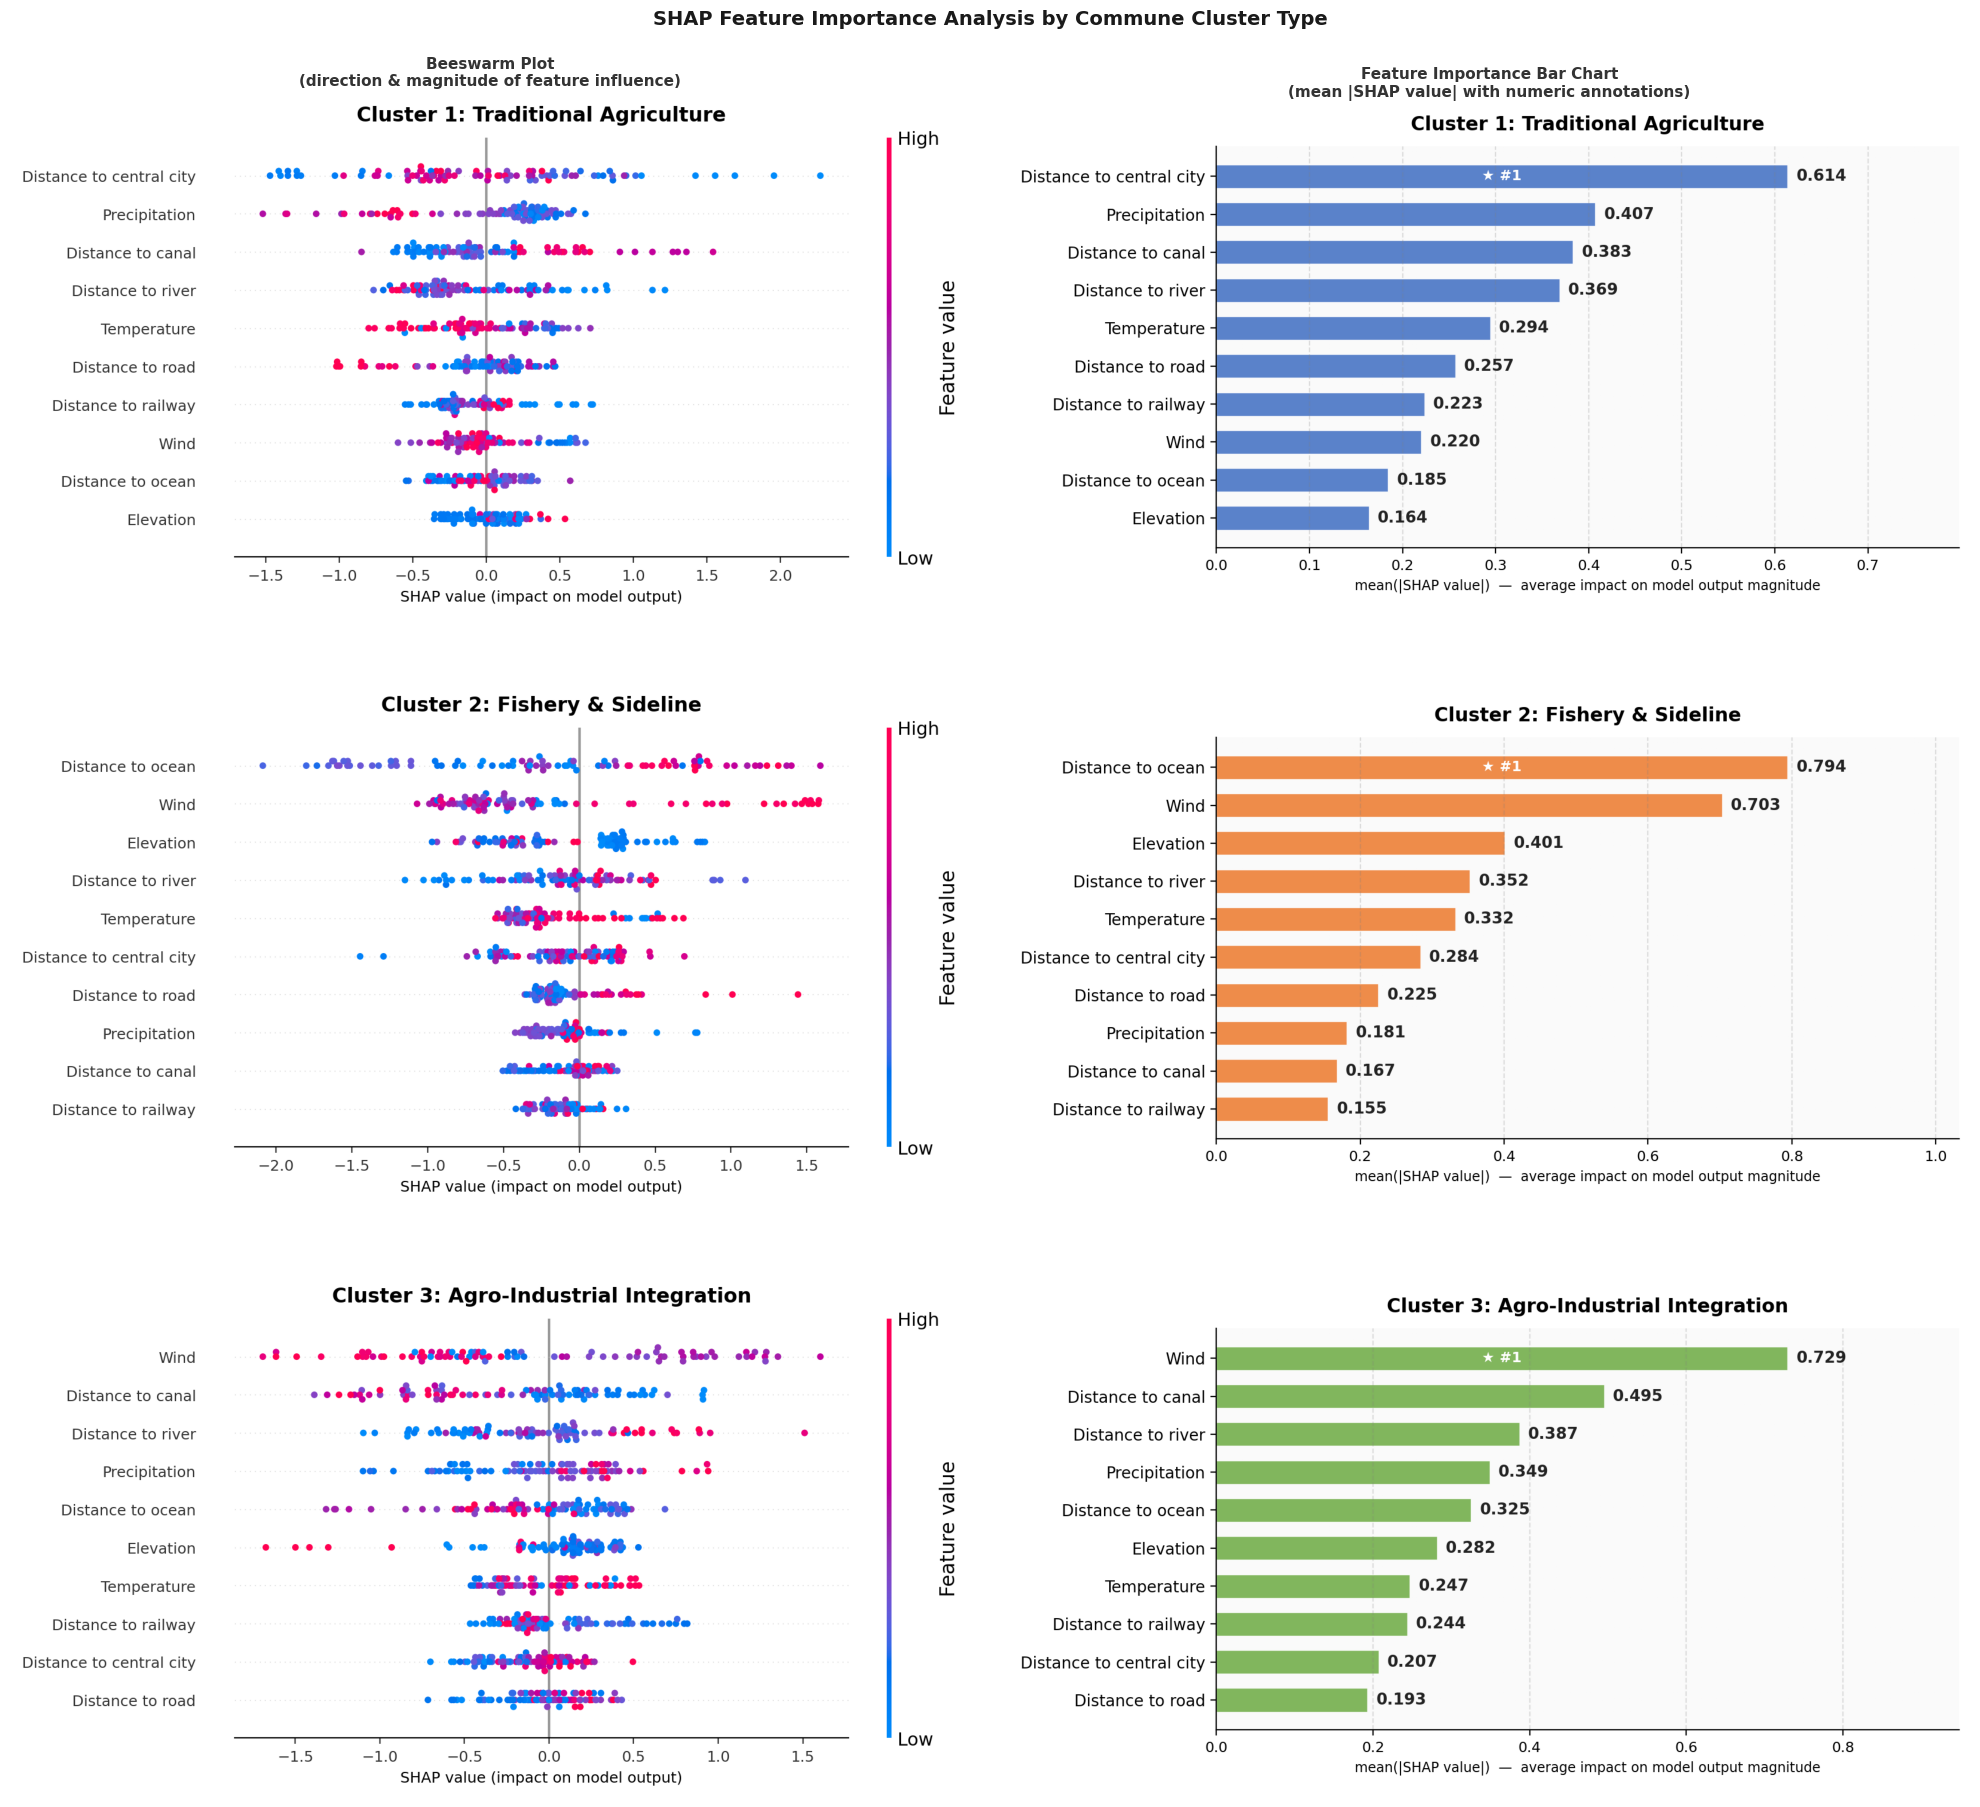


✓ 图已保存：E:\00论文\2025江苏人民公社\JAABE返修1\shap_combined_final.png

各聚类 SHAP 特征重要性（从高到低）

Cluster 1: Traditional Agriculture:
  # 1  Distance to central city       0.6136
  # 2  Precipitation                  0.4070
  # 3  Distance to canal              0.3830
  # 4  Distance to river              0.3686
  # 5  Temperature                    0.2943
  # 6  Distance to road               0.2567
  # 7  Distance to railway            0.2233
  # 8  Wind                           0.2201
  # 9  Distance to ocean              0.1845
  #10  Elevation                      0.1638

Cluster 2: Fishery & Sideline:
  # 1  Distance to ocean              0.7939
  # 2  Wind                           0.7031
  # 3  Elevation                      0.4009
  # 4  Distance to river              0.3525
  # 5  Temperature                    0.3324
  # 6  Distance to central city       0.2836
  # 7  Distance to road               0.2250
  # 8  Precipitation                  0.1812
  # 9  Distance to canal              0

In [11]:
"""
重新生成 SHAP 图：左侧蜂群图 + 右侧带数值标注的条形图
策略：分开生成每行，再拼成最终图，避免 shap.summary_plot 的 gca 冲突

运行前确保以下变量已存在：
    model, X_test, shap_values, features
（即已运行过训练代码）
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shap
import io

# ══════════════════════════════════════════════
# 配置
# ══════════════════════════════════════════════
OUTPUT_FILE = r"E:\00论文\2025江苏人民公社\JAABE返修1\shap_combined_final.png"

cluster_names = {
    0: "Cluster 1: Traditional Agriculture",
    1: "Cluster 2: Fishery & Sideline",
    2: "Cluster 3: Agro-Industrial Integration",
}
bar_colors = ["#4472C4", "#ED7D31", "#70AD47"]

# ══════════════════════════════════════════════
# 准备数据
# ══════════════════════════════════════════════
if isinstance(X_test, np.ndarray):
    X_test_df = pd.DataFrame(X_test, columns=features)
else:
    X_test_df = X_test.copy()

# 计算每类均值绝对SHAP
shap_importance = {}
for i in range(3):
    mean_abs = np.abs(shap_values[i]).mean(axis=0)
    shap_importance[i] = pd.Series(
        mean_abs, index=X_test_df.columns
    ).sort_values(ascending=False)

# ══════════════════════════════════════════════
# 分别生成每行的蜂群图（保存到内存buffer）
# ══════════════════════════════════════════════
bee_buffers = []

for i in range(3):
    fig_bee, ax_bee = plt.subplots(figsize=(8.5, 4.5))
    plt.sca(ax_bee)

    shap.summary_plot(
        shap_values[i],
        X_test_df,
        plot_type="dot",
        show=False,
        plot_size=None,
        color_bar=True,
        max_display=10,
        axis_color="#333333",
    )

    ax_bee = plt.gca()
    ax_bee.set_title(cluster_names[i], fontsize=12, fontweight='bold', pad=10)
    ax_bee.set_xlabel("SHAP value (impact on model output)", fontsize=9)
    ax_bee.tick_params(labelsize=9)
    ax_bee.spines['top'].set_visible(False)
    ax_bee.spines['right'].set_visible(False)
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight',
                facecolor='white')
    buf.seek(0)
    bee_buffers.append(buf)
    plt.close()
    print(f"蜂群图 {i+1}/3 完成")

# ══════════════════════════════════════════════
# 生成每行的条形图（保存到内存buffer）
# ══════════════════════════════════════════════
bar_buffers = []

for i in range(3):
    fig_bar, ax_bar = plt.subplots(figsize=(8.5, 4.5))

    sorted_imp = shap_importance[i].sort_values(ascending=True)
    feat_names = sorted_imp.index.tolist()
    values     = sorted_imp.values
    max_val    = values.max()

    bars = ax_bar.barh(
        feat_names, values,
        color=bar_colors[i], alpha=0.88,
        edgecolor='white', linewidth=0.5,
        height=0.62
    )

    # 每个bar右侧标注数值
    for bar, val in zip(bars, values):
        ax_bar.text(
            val + max_val * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center', ha='left',
            fontsize=10, fontweight='bold',
            color='#222222'
        )

    # 最高bar内部标注星号
    top_bar = bars[-1]
    ax_bar.text(
        values[-1] * 0.5,
        top_bar.get_y() + top_bar.get_height() / 2,
        '★ #1',
        va='center', ha='center',
        fontsize=9, color='white', fontweight='bold'
    )

    ax_bar.set_xlim(0, max_val * 1.30)
    ax_bar.set_title(cluster_names[i], fontsize=12, fontweight='bold', pad=10)
    ax_bar.set_xlabel(
        "mean(|SHAP value|)  —  average impact on model output magnitude",
        fontsize=8.5
    )
    ax_bar.tick_params(axis='y', labelsize=10)
    ax_bar.tick_params(axis='x', labelsize=9)
    ax_bar.grid(axis='x', alpha=0.25, linestyle='--', color='gray')
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.set_facecolor('#FAFAFA')
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight',
                facecolor='white')
    buf.seek(0)
    bar_buffers.append(buf)
    plt.close()
    print(f"条形图 {i+1}/3 完成")

# ══════════════════════════════════════════════
# 拼合：3行 × 2列
# ══════════════════════════════════════════════
print("拼合图片...")
fig_final, axes = plt.subplots(3, 2, figsize=(20, 18))
fig_final.patch.set_facecolor('white')

for i in range(3):
    # 左：蜂群图
    img_bee = mpimg.imread(bee_buffers[i])
    axes[i, 0].imshow(img_bee)
    axes[i, 0].axis('off')

    # 右：条形图
    img_bar = mpimg.imread(bar_buffers[i])
    axes[i, 1].imshow(img_bar)
    axes[i, 1].axis('off')

# 列标题
axes[0, 0].set_title("Beeswarm Plot\n(direction & magnitude of feature influence)",
                      fontsize=11, fontweight='bold', pad=6, color='#333333')
axes[0, 1].set_title("Feature Importance Bar Chart\n(mean |SHAP value| with numeric annotations)",
                      fontsize=11, fontweight='bold', pad=6, color='#333333')

fig_final.suptitle(
    "SHAP Feature Importance Analysis by Commune Cluster Type",
    fontsize=14, fontweight='bold', y=1.01, color='#1a1a1a'
)

plt.subplots_adjust(hspace=0.08, wspace=0.04,
                    left=0.01, right=0.99,
                    top=0.97, bottom=0.01)

plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"\n✓ 图已保存：{OUTPUT_FILE}")

# ══════════════════════════════════════════════
# 打印数值表供核对
# ══════════════════════════════════════════════
print("\n" + "="*55)
print("各聚类 SHAP 特征重要性（从高到低）")
print("="*55)
for i in range(3):
    print(f"\n{cluster_names[i]}:")
    for rank, (feat, val) in enumerate(
        shap_importance[i].sort_values(ascending=False).items(), 1
    ):
        print(f"  #{rank:>2}  {feat:<30} {val:.4f}")


蜂群图 1/3 完成
蜂群图 2/3 完成
蜂群图 3/3 完成
条形图 1/3 完成
条形图 2/3 完成
条形图 3/3 完成
拼合图片...


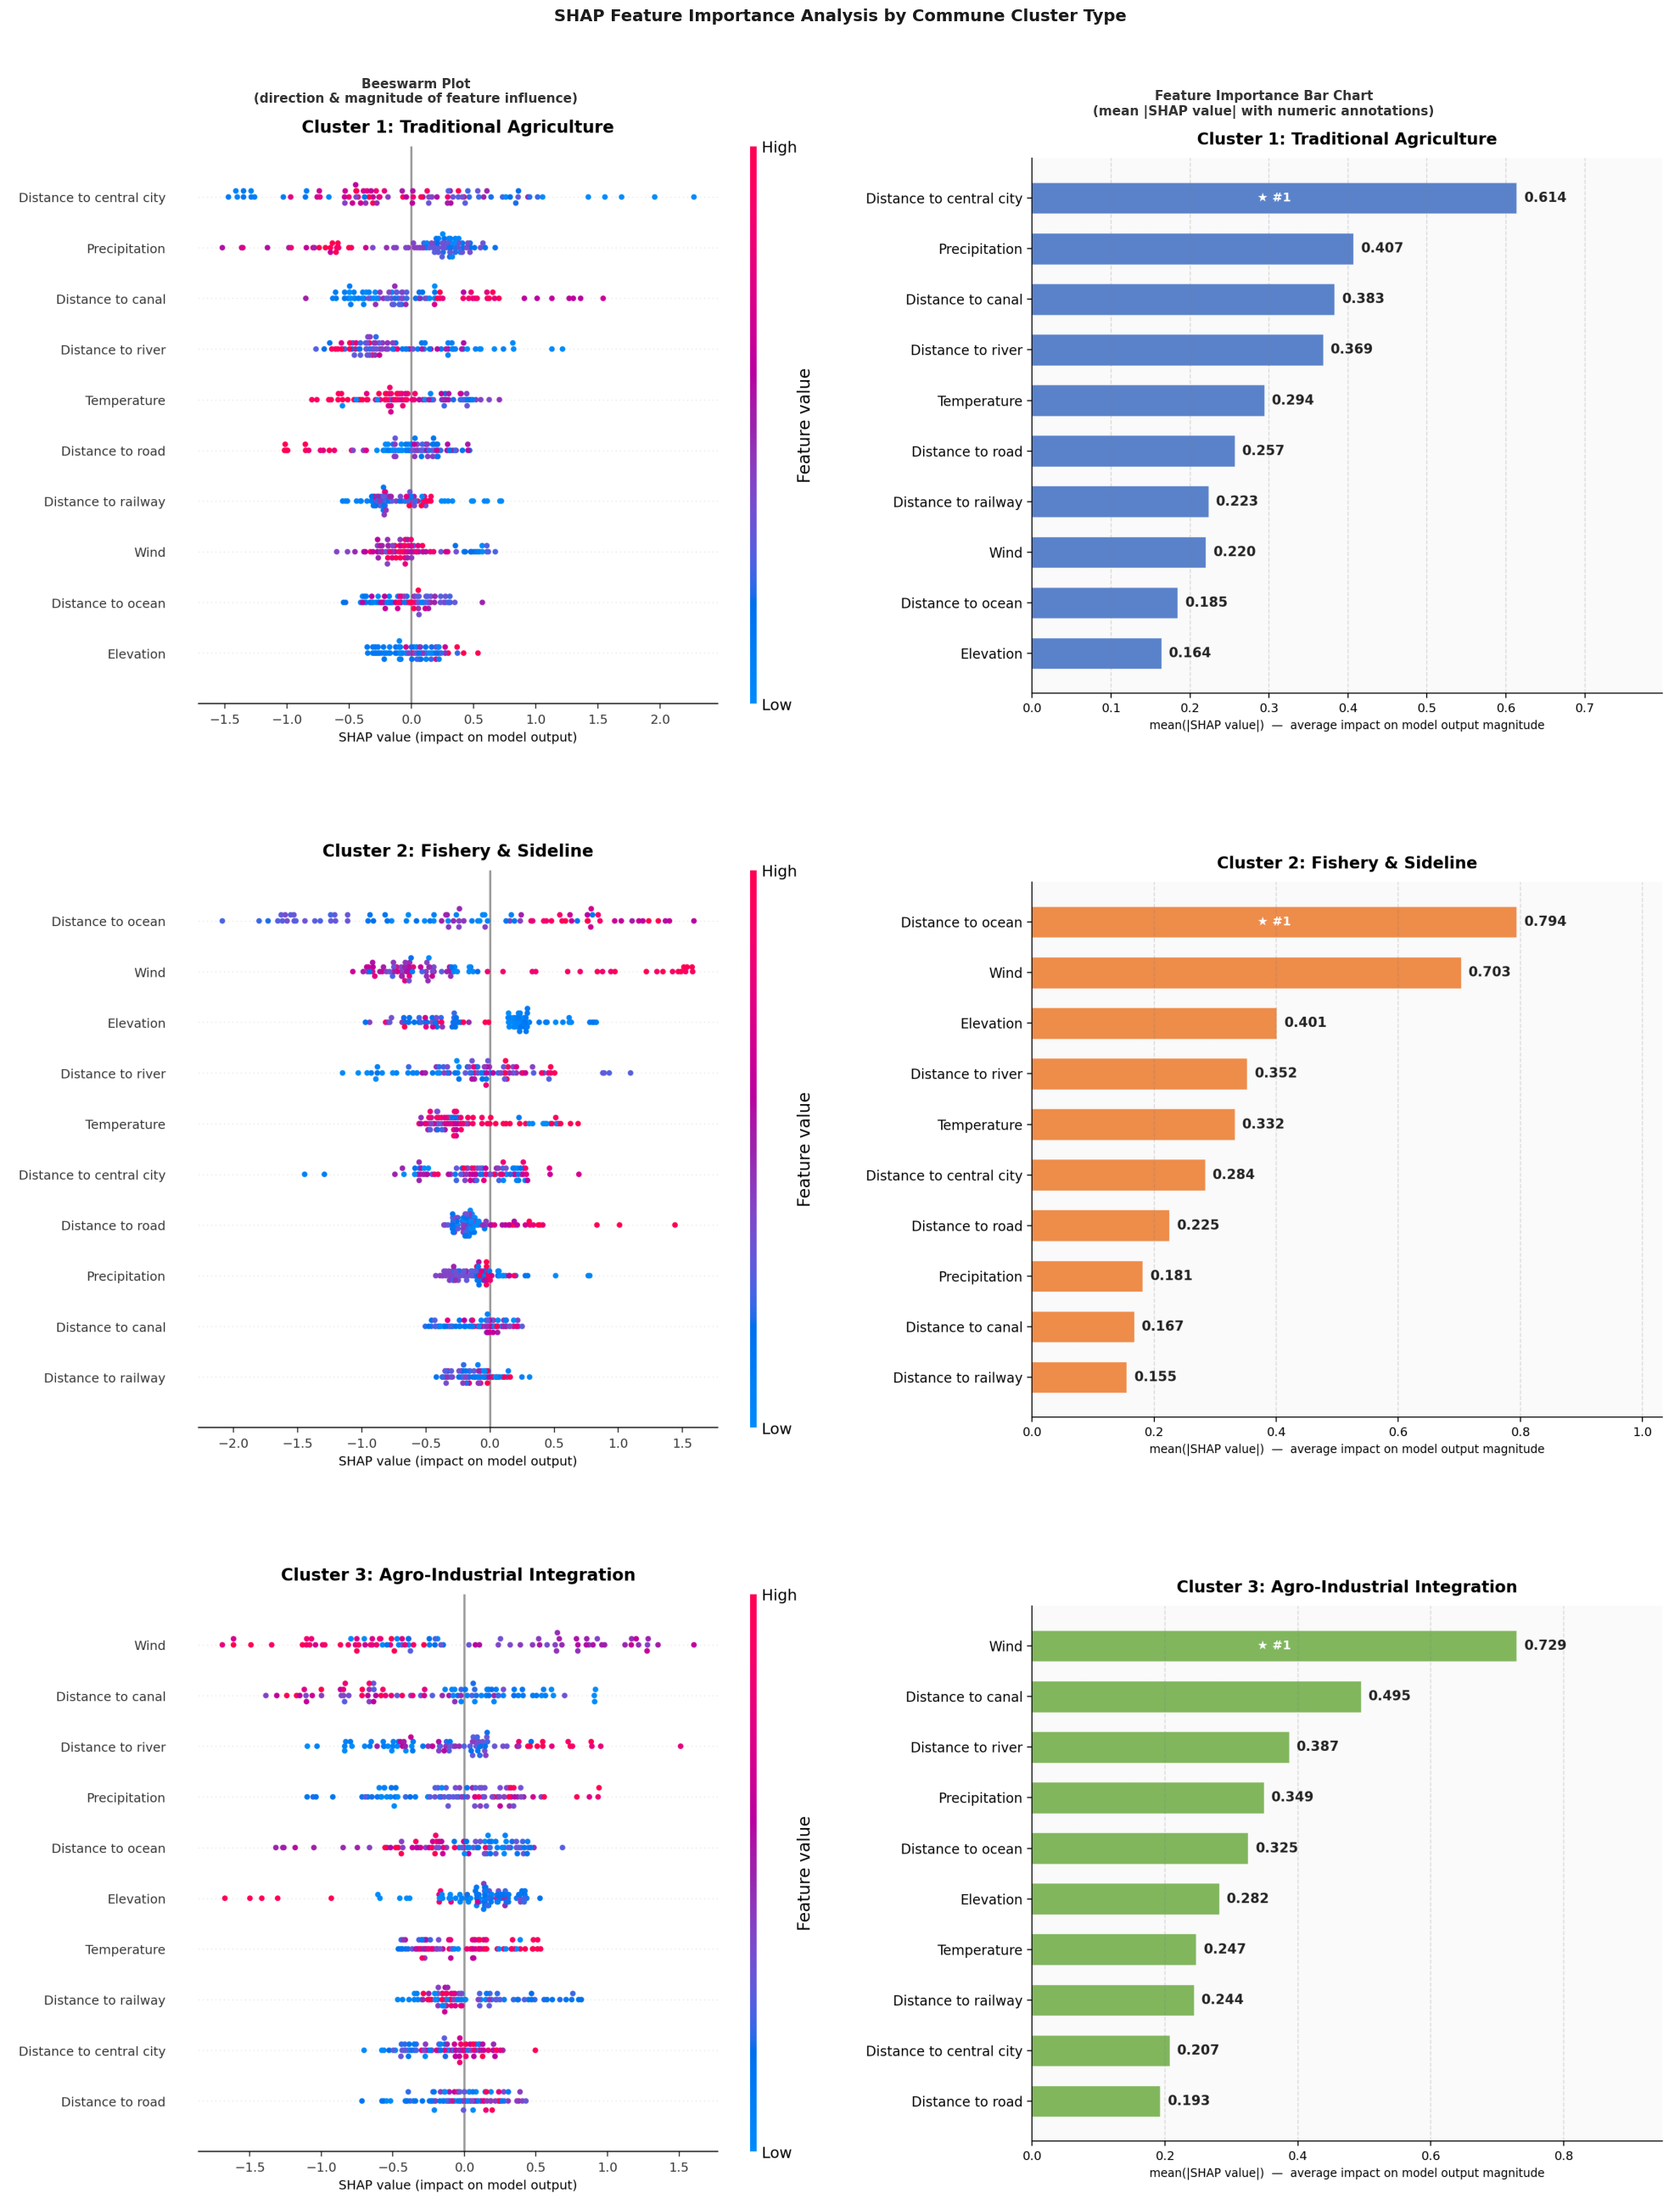


✓ 图已保存：E:\00论文\2025江苏人民公社\JAABE返修1\shap_combined_final.png

各聚类 SHAP 特征重要性（从高到低）

Cluster 1: Traditional Agriculture:
  # 1  Distance to central city       0.6136
  # 2  Precipitation                  0.4070
  # 3  Distance to canal              0.3830
  # 4  Distance to river              0.3686
  # 5  Temperature                    0.2943
  # 6  Distance to road               0.2567
  # 7  Distance to railway            0.2233
  # 8  Wind                           0.2201
  # 9  Distance to ocean              0.1845
  #10  Elevation                      0.1638

Cluster 2: Fishery & Sideline:
  # 1  Distance to ocean              0.7939
  # 2  Wind                           0.7031
  # 3  Elevation                      0.4009
  # 4  Distance to river              0.3525
  # 5  Temperature                    0.3324
  # 6  Distance to central city       0.2836
  # 7  Distance to road               0.2250
  # 8  Precipitation                  0.1812
  # 9  Distance to canal              0

In [12]:
"""
重新生成 SHAP 图：左侧蜂群图 + 右侧带数值标注的条形图
策略：分开生成每行，再拼成最终图，避免 shap.summary_plot 的 gca 冲突

运行前确保以下变量已存在：
    model, X_test, shap_values, features
（即已运行过训练代码）
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shap
import io

# ══════════════════════════════════════════════
# 配置
# ══════════════════════════════════════════════
OUTPUT_FILE = r"E:\00论文\2025江苏人民公社\JAABE返修1\shap_combined_final.png"

cluster_names = {
    0: "Cluster 1: Traditional Agriculture",
    1: "Cluster 2: Fishery & Sideline",
    2: "Cluster 3: Agro-Industrial Integration",
}
bar_colors = ["#4472C4", "#ED7D31", "#70AD47"]

# ══════════════════════════════════════════════
# 准备数据
# ══════════════════════════════════════════════
if isinstance(X_test, np.ndarray):
    X_test_df = pd.DataFrame(X_test, columns=features)
else:
    X_test_df = X_test.copy()

# 计算每类均值绝对SHAP
shap_importance = {}
for i in range(3):
    mean_abs = np.abs(shap_values[i]).mean(axis=0)
    shap_importance[i] = pd.Series(
        mean_abs, index=X_test_df.columns
    ).sort_values(ascending=False)

# ══════════════════════════════════════════════
# 分别生成每行的蜂群图（保存到内存buffer）
# ══════════════════════════════════════════════
bee_buffers = []

for i in range(3):
    fig_bee, ax_bee = plt.subplots(figsize=(8.5, 6.5))
    plt.sca(ax_bee)

    shap.summary_plot(
        shap_values[i],
        X_test_df,
        plot_type="dot",
        show=False,
        plot_size=None,
        color_bar=True,
        max_display=10,
        axis_color="#333333",
    )

    ax_bee = plt.gca()
    ax_bee.set_title(cluster_names[i], fontsize=12, fontweight='bold', pad=10)
    ax_bee.set_xlabel("SHAP value (impact on model output)", fontsize=9)
    ax_bee.tick_params(labelsize=9)
    ax_bee.spines['top'].set_visible(False)
    ax_bee.spines['right'].set_visible(False)
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight',
                facecolor='white')
    buf.seek(0)
    bee_buffers.append(buf)
    plt.close()
    print(f"蜂群图 {i+1}/3 完成")

# ══════════════════════════════════════════════
# 生成每行的条形图（保存到内存buffer）
# ══════════════════════════════════════════════
bar_buffers = []

for i in range(3):
    fig_bar, ax_bar = plt.subplots(figsize=(8.5, 6.5))

    sorted_imp = shap_importance[i].sort_values(ascending=True)
    feat_names = sorted_imp.index.tolist()
    values     = sorted_imp.values
    max_val    = values.max()

    bars = ax_bar.barh(
        feat_names, values,
        color=bar_colors[i], alpha=0.88,
        edgecolor='white', linewidth=0.5,
        height=0.62
    )

    # 每个bar右侧标注数值
    for bar, val in zip(bars, values):
        ax_bar.text(
            val + max_val * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center', ha='left',
            fontsize=10, fontweight='bold',
            color='#222222'
        )

    # 最高bar内部标注星号
    top_bar = bars[-1]
    ax_bar.text(
        values[-1] * 0.5,
        top_bar.get_y() + top_bar.get_height() / 2,
        '★ #1',
        va='center', ha='center',
        fontsize=9, color='white', fontweight='bold'
    )

    ax_bar.set_xlim(0, max_val * 1.30)
    ax_bar.set_title(cluster_names[i], fontsize=12, fontweight='bold', pad=10)
    ax_bar.set_xlabel(
        "mean(|SHAP value|)  —  average impact on model output magnitude",
        fontsize=8.5
    )
    ax_bar.tick_params(axis='y', labelsize=10)
    ax_bar.tick_params(axis='x', labelsize=9)
    ax_bar.grid(axis='x', alpha=0.25, linestyle='--', color='gray')
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.set_facecolor('#FAFAFA')
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=200, bbox_inches='tight',
                facecolor='white')
    buf.seek(0)
    bar_buffers.append(buf)
    plt.close()
    print(f"条形图 {i+1}/3 完成")

# ══════════════════════════════════════════════
# 拼合：3行 × 2列
# ══════════════════════════════════════════════
print("拼合图片...")
fig_final, axes = plt.subplots(3, 2, figsize=(20, 26))
fig_final.patch.set_facecolor('white')

for i in range(3):
    # 左：蜂群图
    img_bee = mpimg.imread(bee_buffers[i])
    axes[i, 0].imshow(img_bee)
    axes[i, 0].axis('off')

    # 右：条形图
    img_bar = mpimg.imread(bar_buffers[i])
    axes[i, 1].imshow(img_bar)
    axes[i, 1].axis('off')

# 列标题
axes[0, 0].set_title("Beeswarm Plot\n(direction & magnitude of feature influence)",
                      fontsize=11, fontweight='bold', pad=6, color='#333333')
axes[0, 1].set_title("Feature Importance Bar Chart\n(mean |SHAP value| with numeric annotations)",
                      fontsize=11, fontweight='bold', pad=6, color='#333333')

fig_final.suptitle(
    "SHAP Feature Importance Analysis by Commune Cluster Type",
    fontsize=14, fontweight='bold', y=1.01, color='#1a1a1a'
)

plt.subplots_adjust(hspace=0.08, wspace=0.04,
                    left=0.01, right=0.99,
                    top=0.97, bottom=0.01)

plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"\n✓ 图已保存：{OUTPUT_FILE}")

# ══════════════════════════════════════════════
# 打印数值表供核对
# ══════════════════════════════════════════════
print("\n" + "="*55)
print("各聚类 SHAP 特征重要性（从高到低）")
print("="*55)
for i in range(3):
    print(f"\n{cluster_names[i]}:")
    for rank, (feat, val) in enumerate(
        shap_importance[i].sort_values(ascending=False).items(), 1
    ):
        print(f"  #{rank:>2}  {feat:<30} {val:.4f}")